In [496]:
import pandas as pd
import numpy as np
import chardet

In [498]:
with open('spam.csv','rb') as file:
    results= chardet.detect(file.read())

results

{'encoding': 'Windows-1252', 'confidence': 0.7257971165545478, 'language': ''}

In [499]:
df=pd.read_csv('spam.csv', encoding='Windows-1252')

In [500]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1759,ham,Do u ever get a song stuck in your head for no...,NaN,NaN,NaN
480,ham,"Almost there, see u in a sec",NaN,NaN,NaN
3508,ham,Hi Petey!noiåÕm ok just wanted 2 chat coz aven...,NaN,NaN,NaN
5250,spam,Urgent! Please call 09061213237 from a landlin...,NaN,NaN,NaN
3848,ham,U in town alone?,NaN,NaN,NaN
3475,ham,"I can probably come by, everybody's done aroun...",NaN,NaN,NaN
3904,spam,Do you want a new video handset? 750 anytime a...,NaN,NaN,NaN
4929,spam,"Hi, the SEXYCHAT girls are waiting for you to ...",NaN,NaN,NaN
5348,ham,Do I? I thought I put it back in the box,NaN,NaN,NaN
4265,ham,The greatest test of courage on earth is to be...,NaN,NaN,NaN


In [501]:
#Data cleaning
#EDA
#Text preprocessing
#model building
#evaluation
#improvements
#website
#deployment

## 1. Data Cleaning


In [507]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [509]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [511]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

we are droping last 3 columns

In [514]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace= True, axis=1)

In [516]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Renaming the columns

In [519]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [521]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [523]:
from sklearn.preprocessing import LabelEncoder

In [525]:
encoder= LabelEncoder()

In [527]:
df['target']=encoder.fit_transform(df["target"])

In [529]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [531]:
#check for duplicate values
df.duplicated().sum()

np.int64(403)

In [533]:
df.drop_duplicates(keep='first')

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


## 2. EDA

In [536]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

In [538]:
import seaborn as sns
import matplotlib.pyplot as plt

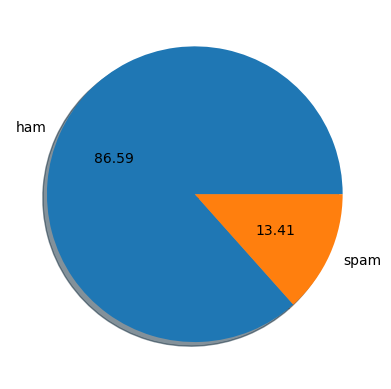

In [540]:
plt.pie(df["target"].value_counts(), labels=['ham','spam'], shadow=True, autopct='%0.2f')
plt.show()

In [542]:
#data is imblanced as spam in less and ham is less.

In [544]:
import nltk

In [546]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nishanknitinshah/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [548]:
df["no_characters"]=df['text'].apply(len)

In [550]:
df

,target,text,no_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [552]:
df["no_of_words"]= df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [553]:
df

,target,text,no_characters,no_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [554]:
df['no_of_sentence']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [557]:
type(df['no_characters'][0])

numpy.int64

In [560]:
df[['no_characters','no_of_words','no_of_sentence']].describe()

,no_characters,no_of_words,no_of_sentence
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


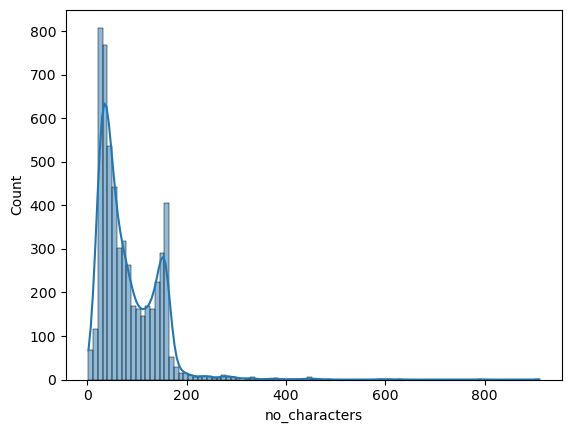

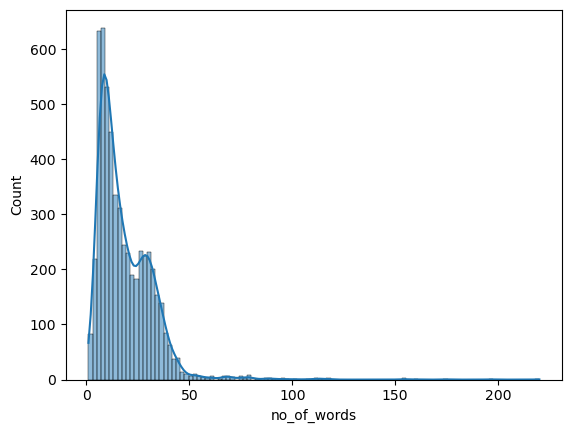

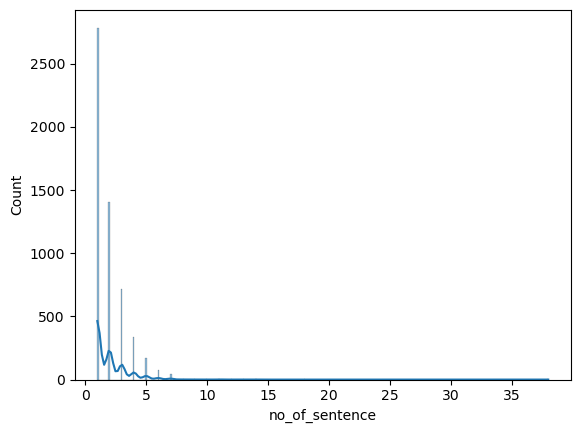

In [562]:
columns=df.columns.to_list()[2:]
for i in columns:
    sns.histplot(df[i],kde=True)
    plt.show()

<Axes: xlabel='no_characters', ylabel='Count'>

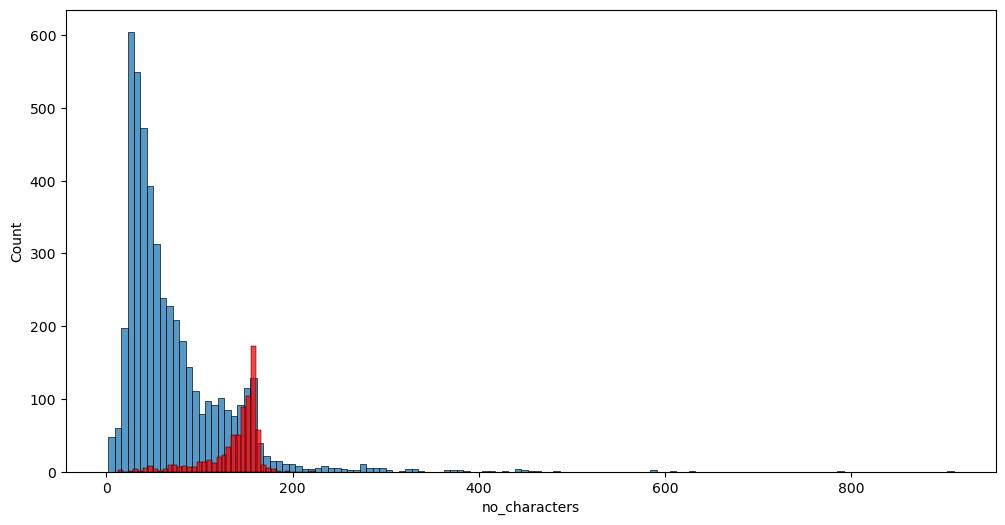

In [563]:
#lets seperatly analyse spam and ham

plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['no_characters'])
sns.histplot(df[df['target']==1]['no_characters'],color='red')

<Axes: xlabel='no_of_words', ylabel='Count'>

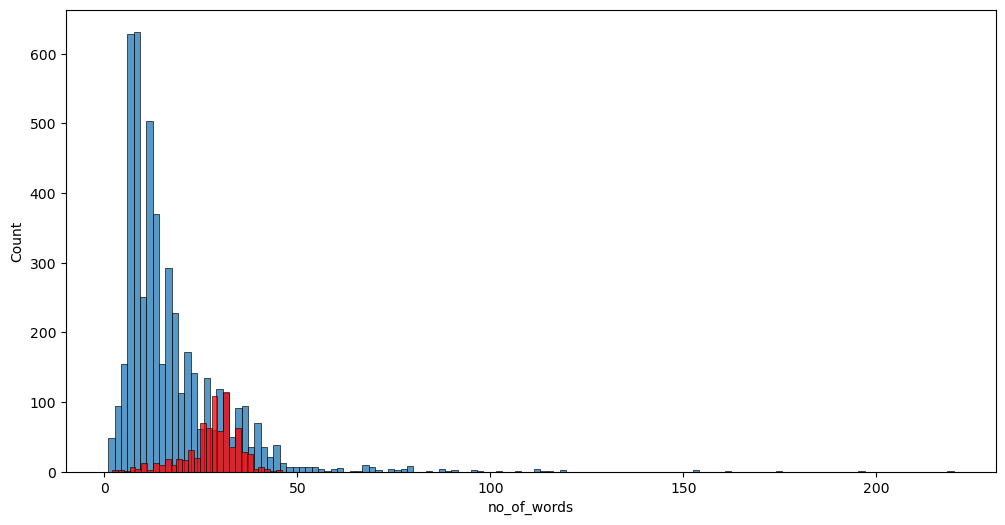

In [564]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['no_of_words'])
sns.histplot(df[df['target']==1]['no_of_words'],color='red')

<Axes: xlabel='no_of_sentence', ylabel='Count'>

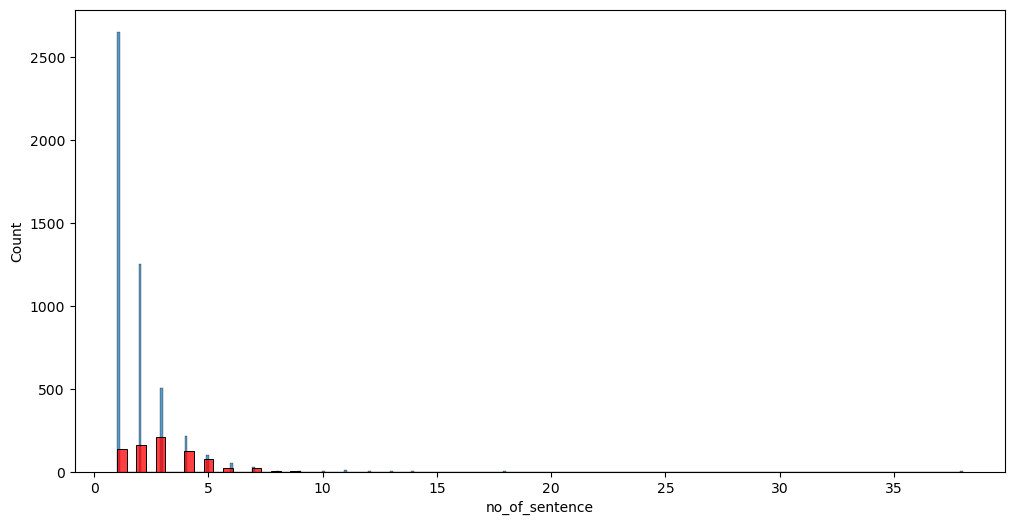

In [565]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['no_of_sentence'])
sns.histplot(df[df['target']==1]['no_of_sentence'],color='red')

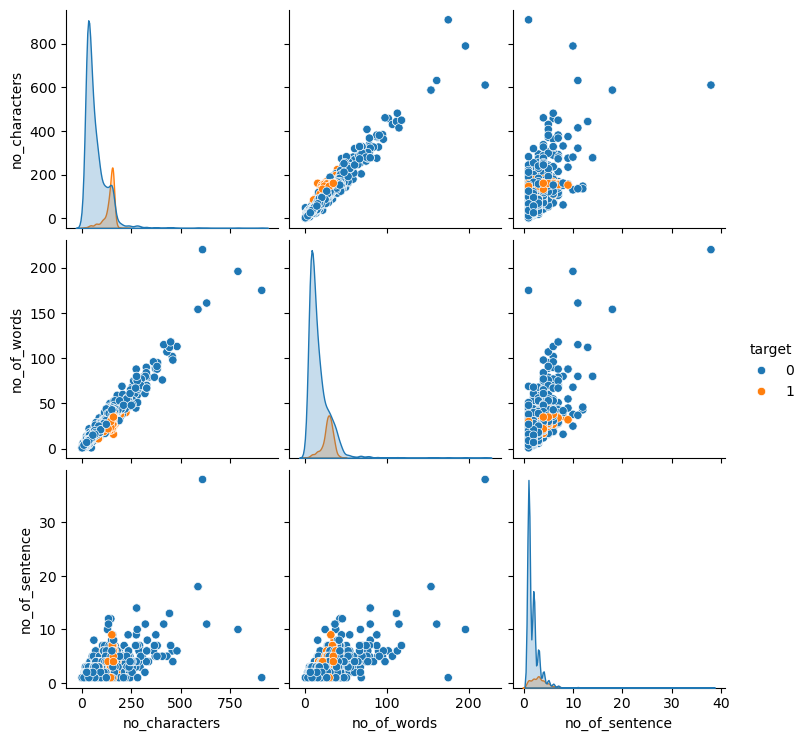

In [566]:
sns.pairplot(df, hue= 'target')

In [577]:
df

,target,text,no_characters,no_of_words,no_of_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [627]:
lists=df.iloc[:,[0,2,3,4]]

In [629]:
lists

,target,no_characters,no_of_words,no_of_sentence
0,0,111,24,2
1,0,29,8,2
2,1,155,37,2
3,0,49,13,1
4,0,61,15,1
...,...,...,...,...
5567,1,161,35,4
5568,0,37,9,1
5569,0,57,15,2
5570,0,125,27,1


<Axes: >

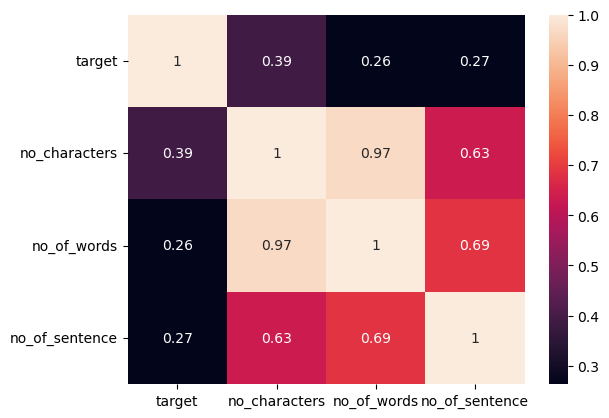

In [631]:
sns.heatmap(lists.corr(),annot=True)

## 3. Data Preprocessing

In [634]:
#lower
#tokenization
#emove stopwords
#remove special characters and puncuation
#stemming


In [652]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nishanknitinshah/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [678]:
import string
from nltk.stem.porter import PorterStemmer

In [686]:
def transfor(a):
    text=a.lower()

    text= nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        ps=PorterStemmer()
        y.append(ps.stem(i))
        
        
    
            
        
    return y
    



In [693]:
transfor("My name is Nihsank 20 % $@ 12das 1@ i am on the roof top i ma runnig i AM JOGGING, i AM DANCING")

['name', 'nihsank', '20', '12da', '1', 'roof', 'top', 'runnig', 'jog', 'danc']

In [700]:
# df['transfored_text']
df['tranformed_text']=df['text'].apply(transfor)

In [702]:
df

,target,text,no_characters,no_of_words,no_of_sentence,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,"[2nd, time, tri, 2, contact, u, pound, prize, ..."
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,"[b, go, esplanad, fr, home]"
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,"[piti, mood, suggest]"
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,"[guy, bitch, act, like, interest, buy, someth,..."


In [712]:
from wordcloud import WordCloud

In [710]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [748]:
wc=WordCloud(height=500, width=500,min_font_size=20,background_color='white')



In [777]:
spam_wc=wc.generate(df[df['target'] == 1]["tranformed_text"].astype(str).str.cat(sep=" "))


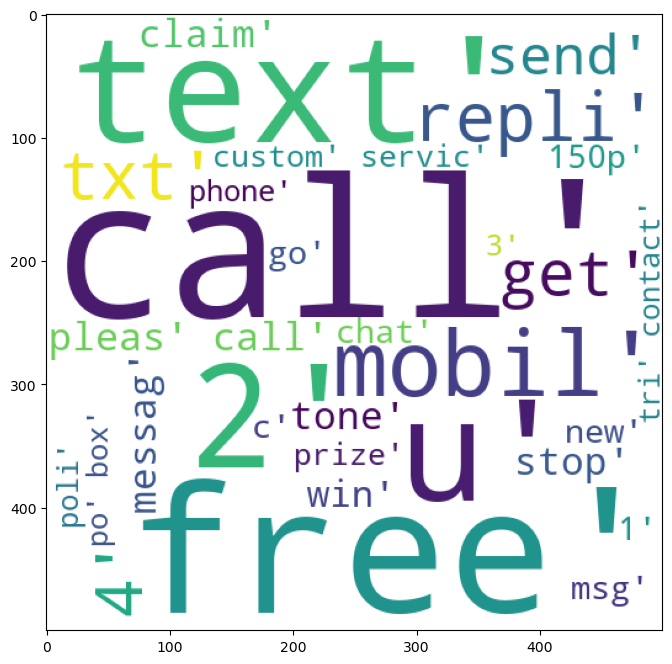

In [779]:
plt.figure(figsize=(12,8))
plt.imshow(spam_wc)

In [781]:
hpam_wc=wc.generate(df[df['target'] == 0]["tranformed_text"].astype(str).str.cat(sep=" "))

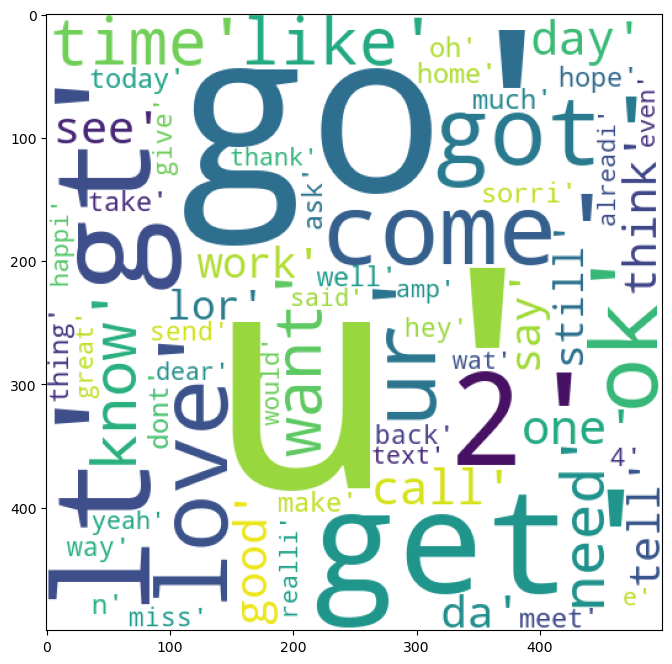

In [783]:
plt.figure(figsize=(12,8))
plt.imshow(hpam_wc)